# Semantic Invariance (SI) and Semantically Orthogonal Artifact Projection (SOAP)

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import os
import torch
import matplotlib.pyplot as plt

In [4]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cuda


This notebook serves as a playground for testing out the SI score and SOAP. Start by loading a pretrained model. We have provided some example models in `get_models.py`, or you can load your own.

In [60]:
# Get a pretrained model
from get_models import get_dense_backbone, get_patch_size
modelname = 'dinov2_base'
model = get_dense_backbone(modelname).to(device).eval()
patch_size = get_patch_size(modelname)

## How to calculate the Semantic Orthogonal Projector (SOaP)

Start by loading a dataset for estimating the covariance and calculating Semantic Invariance scores. This can for example be ImageNet, but the result is very similar with smaller datasets as well.

In [ ]:
# Standard transforms
import torchvision as tv
mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])
imgsize = 224
aug = tv.transforms.Compose([
        tv.transforms.RandomResizedCrop((imgsize, imgsize), (1., 1.)),
        tv.transforms.ToTensor(),
        tv.transforms.Normalize(mean, std),
    ])

# Load ImageNet or another dataset to estimate the embedding covariance of the model. Remember to apply the aug!
data = ...

batch_size = 512
dataloader = torch.utils.data.DataLoader(data, batch_size, num_workers=4, prefetch_factor=2, pin_memory=True)

In [ ]:
# Useful for un-normalizing images for visualization
inv_normalize = tv.transforms.Normalize(                                                                                                                  
      mean=[-m/s for m,s in zip(mean, std)],                                                                                                                
      std=[1/s for s in std]                                                                                                                                
  ) 

The SOaP projection only needs to be calculated once. The results are saved in a `weights` folder, unless otherwise specified. If you want the projection to be calculated from scratch, you have to delete the files from the `weights` folder.

In [ ]:
from fit_projector import fit_WCE, fit_projector

# Estimate the covariance
cov_data = fit_WCE(model, dataloader, modelname, device)

In [ ]:
from soap.synth import SynthesizedDataSet

# Synthetic dataset generator
dataset_length = len(data)
dataloader_synth = SynthesizedDataSet(size=imgsize, channels=3, 
    batch_size=dataloader.batch_size, length=dataset_length)

# Fit the SOAP projector
projector = fit_projector(
    model, cov_data, dataloader, dataloader_synth,
    modelname, imgsize, patch_size, device).to(device)

The checkpoints can be loaded from the `weights` folder at any time.

In [ ]:
from soap import SOAP, WelfordChanEstimator

# Load the WelfordChan checkpoint for the covariance estimation
cov_data = WelfordChanEstimator.deserialize(f'weights/{modelname}_cov.pth').to(device)

# Load the SOAP projector checkpoint
projector = SOAP.deserialize(f'weights/{modelname}_projector.pth').to(device)

# Alternatively, the following recalculates the SOAP projector from the precomputed responses to the real and synthetic datasets
projector = SOAP.from_modelname(modelname, 'weights').to(device)

## Semantic Invariance

The semantic invariace score can be calculated by...

Text(0.5, 0.98, 'Semantic Invariance (SI) for dinov2_base')

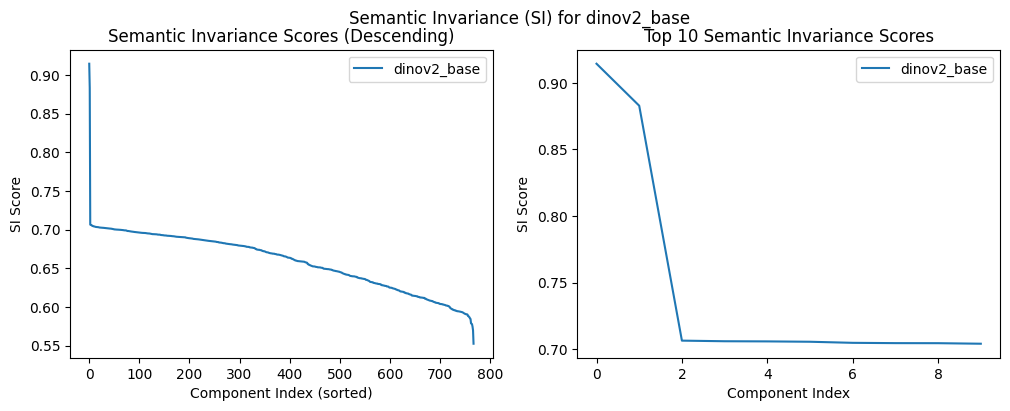

In [65]:
from soap.soap import semantic_invariance_score

p_data = torch.load(f'weights/{modelname}_agg_patch_responses.pth').to(device)
p_synth = torch.load(f'weights/{modelname}_agg_patch_responses_synth.pth').to(device)
si_scores = semantic_invariance_score(p_data, p_synth)
sorted_scores, sorted_idx = torch.sort(si_scores, descending=True)

# Plot the SI scores in descending order
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(sorted_scores.cpu(), label={modelname})
axs[0].set_title('Semantic Invariance Scores (Descending)')
axs[0].set_xlabel('Component Index (sorted)')
axs[0].set_ylabel('SI Score')
axs[0].legend()
axs[1].plot(sorted_scores.cpu()[:10], label={modelname})
axs[1].set_title('Top 10 Semantic Invariance Scores')
axs[1].set_xlabel('Component Index')
axs[1].set_ylabel('SI Score')
axs[1].legend()
fig.suptitle(f'Semantic Invariance (SI) for {modelname}')

In [66]:
# Which principal components are the most semantically invariant?
print(f'#1: Principal component {sorted_idx[0]} with SI score {sorted_scores[0]:.4f}')
print(f'#2: Principal component {sorted_idx[1]} with SI score {sorted_scores[1]:.4f}')
print(f'#3: Principal component {sorted_idx[2]} with SI score {sorted_scores[2]:.4f}')

#1: Principal component 0 with SI score 0.9144
#2: Principal component 2 with SI score 0.8829
#3: Principal component 234 with SI score 0.7064


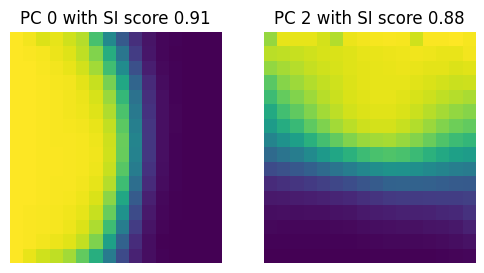

In [67]:
# Visualize the average activation of the two principal components with highest SI score
fig, axs = plt.subplots(1, 2, figsize=(6,3))
axs[0].imshow(p_data[:,:,sorted_idx[0]].cpu().numpy(), aspect='auto')
axs[0].set_title(f'PC {sorted_idx[0]} with SI score {sorted_scores[0]:.2f}')
axs[1].imshow(p_data[:,:,sorted_idx[1]].cpu().numpy(), aspect='auto')
axs[1].set_title(f'PC {sorted_idx[1]} with SI score {sorted_scores[1]:.2f}')
for ax in axs: ax.axis('off')

Let's take an example image and inspect the responses of the two principal components with the highest SI score.

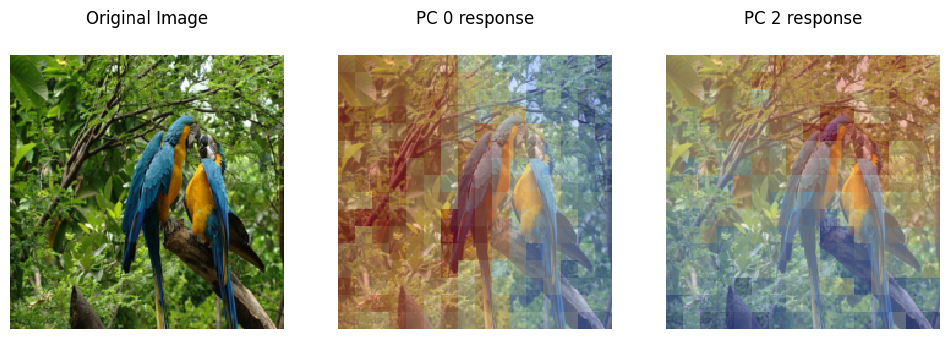

In [112]:
from PIL import Image
import torch.nn.functional as F

img = Image.open('assets/images/n01818515_macaw.JPEG') # Example image
img = aug(img).unsqueeze(0).to(device)

# Get the patch embeddings from the model
with torch.no_grad():
    out = model.forward(img)

# Get the indices of the top 2 most semantically invariant componentsh
indices = sorted_idx[:2] 
responses = []
for idx in indices:
    # Calculate the response of the selected principal component
    W, b = cov_data.get_truncated_weights_and_biases_at_ranks([idx])
    res = out @ W + b
    responses.append(res)

# Visualize
cmap = plt.get_cmap("coolwarm")
alpha = 0.5
p = imgsize//patch_size

fig, ax = plt.subplots(1,1+len(indices), figsize=(12,4))
ax[0].set_title('Original Image')
ax[0].matshow(inv_normalize(img).cpu().squeeze().permute(1,2,0))
for i in range(len(indices)):
    ax[i+1].set_title(f'PC {indices[i]} response')
    ax[i+1].matshow(inv_normalize(img).cpu().squeeze().permute(1,2,0))
    mask = F.interpolate(responses[i].view(1,1,p,p), scale_factor=patch_size).squeeze()
    ax[i+1].matshow(mask.cpu(), cmap='coolwarm', alpha=0.5)
for a in ax: a.axis('off')

## Salient segmentation 

In [113]:
from salient.bilateral import *
from salient.ncut import *
from salient.metrics import *
from salient.util import *
from soap import SOAP, WelfordChanEstimator

In [114]:
# Load a pretrained model and projector
modelname = 'dinov2_base'
features = 'out'

model = get_dense_backbone(modelname).to(device).eval()
patch_size = get_patch_size(modelname)

# projector = SOAP.deserialize(f'weights/{modelname}_projector.pth').to(device)
projector = SOAP.from_modelname(modelname, 'weights',).to(device)
cov_data = WelfordChanEstimator.deserialize(f'weights/{modelname}_cov.pth').to(device)

In [ ]:
# Load ECSSD dataset
ecssd = ...

# Principal component salient guide
pca_guide_dim = -2 # -2 for DINOv2, -1 for CAPI
flip_guide = True

from functools import partial
from main_salient import get_guide_response
W, b = cov_data.get_truncated_weights_and_biases_at_indices([pca_guide_dim])
get_guide = partial(get_guide_response, W=W.mT, b=b, flip=flip_guide)

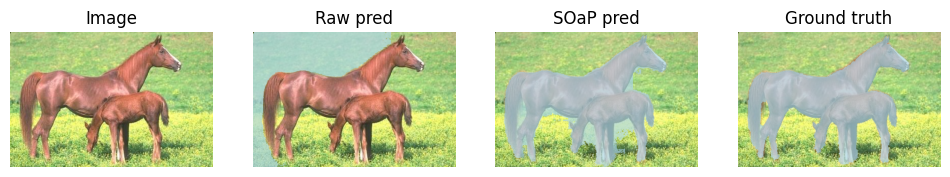

In [123]:
# Choose image
i = 6
img, seg = ecssd[i]

# Convert input image to tensor
I_resize, w, h, feat_w, feat_h = resize_pil(img, patch_size)
trans = tv.transforms.Compose([
    tv.transforms.ToTensor(),
    tv.transforms.Normalize((0.485, 0.456, 0.406),
                            (0.229, 0.224, 0.225)),])
tensor = trans(I_resize).unsqueeze(0)

# Get patch features from model
feat = model(tensor.to(device), vit_feat=features)[0]

# Get guide from pca
if pca_guide_dim is not None:
    guide = get_guide(feat).cpu().numpy()
else:
    guide = None

# Apply SOaP
corr_feat = projector(feat)

# TokenCut on raw feats
seed, bipartition, eigvec = ncut(
    feat.mT, dims=[feat_h, feat_w], 
    scales=[patch_size, patch_size], init_image_size=[h,w], 
    guide=None, foregound_selection='vmax', tau=0.3)

# Bilateral solver for edge refinement
output_solver, binary_solver = bilateral_solver_output(
    img, bipartition, 
    sigma_spatial = 16, 
    sigma_luma = 16, 
    sigma_chroma = 8
)
pred = output_solver

# TokenCut on corrected feats
seed, bipartition, eigvec = ncut(
    corr_feat.mT, dims=[feat_h, feat_w], 
    scales=[patch_size, patch_size], init_image_size=[h,w], 
    guide=guide, foregound_selection='pca', tau=0.3)

# Bilateral solver for edge refinement
output_solver, binary_solver = bilateral_solver_output(
    img, bipartition, 
    sigma_spatial = 16, 
    sigma_luma = 16, 
    sigma_chroma = 8
)
soap_pred = output_solver

# Visualize
org_img = np.array(img)
pred_img = mask_color_compose(org_img, pred)
soap_pred_img = mask_color_compose(org_img, soap_pred)
gt = mask_color_compose(org_img, seg)

imgs = [org_img, pred_img, soap_pred_img, gt]
labels = ['Image', 'Raw pred', 'SOaP pred', 'Ground truth']
fig, axes = plt.subplots(1, 4, figsize=(12, 4))
for ax, im, lab in zip(axes, imgs, labels):
    ax.imshow(im)
    ax.axis("off")
    ax.set_title(lab)
plt.show()